In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [2]:
X, y = load_iris(return_X_y=True)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [5]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [6]:
y_pred = model.predict(X_test)

In [7]:
print(model.score(X_test, y_test))

1.0


In [8]:
from sklearn.svm import SVC

model = SVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(model.score(X_test, y_test))

1.0


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

pipe.fit(X_train, y_train)

print(pipe.score(X_test, y_test))

1.0


In [10]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 1.3 MB/s eta 0:01:20
   ---------------------------------------- 0.0/101.7 MB 1.3 MB/s eta 0:01:20
   ---------------------------------------- 0.1/101.7 MB 563.7 kB/s eta 0:03:01
   ---------------------------------------- 0.5/101.7 MB 3.2 MB/s eta 0:00:33
    --------------------------------------- 2.2/101.7 MB 11.7 MB/s eta 0:00:09
   - -------------------------------------- 3.6/101.7 MB 15.5 MB/s eta 0:00:07
   -- ------------------------------------- 5.9/101.7 MB 19.9 MB/s eta 0:00:05
   -- ------------------------------------- 6.3/101.7 MB 21.2 MB/s eta 0:00:05
   -- ------------------------------------- 7.3/101.7 MB 19.4 MB/s eta 0:00:05
   --- ------------------------------------ 9.5/101.7 MB 23.3 MB/s eta 0:00:04

In [11]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(model.score(X_test, y_test))

1.0


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
0.9666666666666668


In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid=params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 3, 'n_estimators': 50}
0.95


In [17]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

model = RandomForestClassifier()

model.fit(X_train, y_train)

importance = model.feature_importances_

print(importance)

[0.0828758  0.03238308 0.47367896 0.41106216]


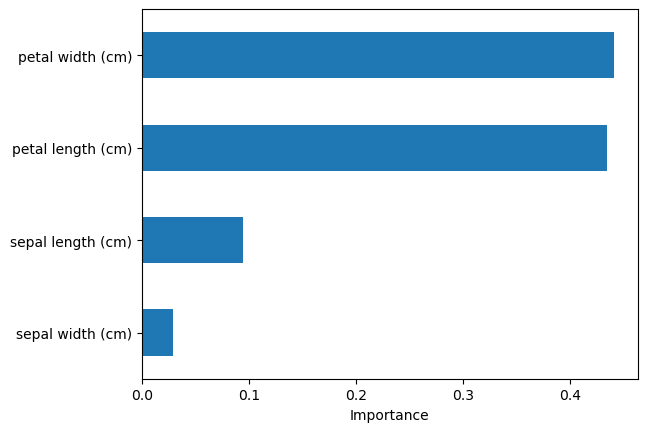

In [24]:
import matplotlib.pyplot as plt

data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.show()